<p><font color="blue">
    <h3 align="center">Laboratoire d'Etudes Statistiques et de Conception d'Applications et Logiciels</h3>
    <h1 align="center">L.E.S.C.A.L.</h3>
    <h1 align="center">--------------------------------------</h3>
    <h2 align="center">Cedoriase Academy For Artificial Intelligence</h2>
    <h4 align="center">+229 0166233516 / cedoriaseacademy@lescal-soc.com</h4>
    <h1 align="center">--------------------------------------</h3>
    <h2 align="center">TP : Analyse exploratoire des données et Apprentissage automatique</h2>
</font></p>

## Analyse exploratoire des données (EDA) et prédiction des prix des voitures

Nous utilisons un ensemble de données contenant des informations sur divers modèles de voitures, en explorant les facteurs qui influencent leurs prix. L'objectif est d'obtenir des informations sur l'ensemble de données, d'identifier des tendances et de préparer les données pour la construction de modèles prédictifs des prix des voitures.


## Présentation de l'ensemble de données

L'ensemble de données comprend des détails tels que le type de carrosserie (car body type), la marque (brand), le modèle (model), la couleur (color) et diverses caractéristiques numériques telles que la longueur (length), la largeur (width), la hauteur (height) et le prix (price). De plus, des caractéristiques catégorielles telles que la transmission (transmission), le type de carburant (fuel type) et la boîte de vitesses (gear box) sont incluses. L'ensemble de données offre une vue complète des caractéristiques de différentes voitures.


## Objectifs

1. Explorer la distribution des prix des voitures et identifier les valeurs aberrantes.
2. Visualiser la relation entre les types de carrosserie et les prix.
3. Analyser la distribution des types de carburant et des transmissions.
4. Créer des modèles prédictifs pour estimer les prix des voitures.



### Librairies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score

plt.style.use("ggplot")

### A- Analyse exploratoire des données

#### 1- Charger les données

In [2]:
df= pd.read_csv("finaldata.csv")

#### 2- Afficher les 10 premières lignes

In [3]:
df.head(10)

,Body,Transmission,Fuel,Brand,Model,Price,Color,Length,Width,Height,Wheel Base,Gear Box,Seats,Cargo Volume,Max Torque At
0,hatchback,manual,cng,maruti,maruti wagon r,370000,silver,3599.0,1495.0,1700.0,2400.0,5 speed,5.0,180.0,3500.0
1,hatchback,manual,cng,maruti,maruti celerio,365000,grey,3600.0,1600.0,1560.0,2425.0,5 speed,5.0,235.0,3500.0
2,sedan,manual,cng,honda,honda amaze,421000,silver,3990.0,1680.0,1505.0,2405.0,5 speed,5.0,400.0,4500.0
3,hatchback,manual,cng,maruti,maruti wagon r,240000,silver,3595.0,1475.0,1700.0,2400.0,5 speed,5.0,400.0,3500.0
4,muv,manual,cng,maruti,maruti ertiga,1175000,white,4395.0,1735.0,1690.0,2740.0,5 speed,7.0,400.0,4200.0
5,hatchback,manual,cng,maruti,maruti wagon r,250000,white,3599.0,1495.0,1700.0,2400.0,5 speed,5.0,180.0,3500.0
6,hatchback,manual,cng,maruti,maruti alto,145000,blue,3495.0,1475.0,1460.0,2360.0,5 speed,5.0,180.0,3000.0
7,hatchback,manual,cng,hyundai,hyundai grand i10,465000,grey,3765.0,1660.0,1520.0,2425.0,5 speed,5.0,256.0,4000.0
8,hatchback,manual,cng,maruti,maruti wagon r,560000,silver,3655.0,1620.0,1675.0,2435.0,5 speed,5.0,341.0,3500.0
9,hatchback,manual,cng,maruti,maruti wagon r,215000,silver,3599.0,1495.0,1700.0,2400.0,5 speed,5.0,180.0,3500.0


#### 4- Quelques informations numériques sur les données

#### Nbre de lignes et de colonnes

In [4]:
df.shape

(34104, 15)

#### Informations sur les variables

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34104 entries, 0 to 34103
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Body           34104 non-null  object 
 1   Transmission   34104 non-null  object 
 2   Fuel           34104 non-null  object 
 3   Brand          34104 non-null  object 
 4   Model          34104 non-null  object 
 5   Price          34104 non-null  int64  
 6   Color          34104 non-null  object 
 7   Length         34104 non-null  float64
 8   Width          34104 non-null  float64
 9   Height         34104 non-null  float64
 10  Wheel Base     34104 non-null  float64
 11  Gear Box       34104 non-null  object 
 12  Seats          34104 non-null  float64
 13  Cargo Volume   34104 non-null  float64
 14  Max Torque At  34104 non-null  float64
dtypes: float64(7), int64(1), object(7)
memory usage: 3.9+ MB


#### Statistiques descriptives sur les variables numériques (Interpréter)

In [6]:
df.describe()

,Price,Length,Width,Height,Wheel Base,Seats,Cargo Volume,Max Torque At
count,3.410400e+04,34104.000000,34104.000000,34104.000000,34104.000000,34104.000000,34104.000000,34104.000000
mean,8.193639e+05,4120.563893,1727.399982,1578.591221,2549.004340,5.243696,360.991262,3176.838098
std,3.195303e+06,403.674152,130.394317,116.262239,157.966782,0.735884,131.716885,1027.281323
min,1.196300e+04,2752.000000,1312.000000,1165.000000,1840.000000,0.000000,20.000000,160.000000
25%,3.190000e+05,3795.000000,1680.000000,1495.000000,2425.000000,5.000000,256.000000,2125.000000
50%,5.350000e+05,3995.000000,1722.000000,1530.000000,2520.000000,5.000000,350.000000,3400.000000
75%,8.900000e+05,4440.000000,1790.000000,1643.000000,2650.000000,5.000000,465.000000,4000.000000
max,5.500006e+08,5982.000000,2236.000000,2075.000000,3772.000000,14.000000,2055.000000,21800.000000


#### Identification des valeurs manquantes

Utiliser : df.isnull().sum()

C'est une méthode rapide et efficace pour :

- Identifier les colonnes contenant des valeurs manquantes.

- Quantifier le nombre de valeurs manquantes dans chaque colonne.

- Préparer les données pour un traitement ultérieur (par exemple, imputation, suppression des lignes/colonnes).

In [7]:
df.isnull()

,Body,Transmission,Fuel,Brand,Model,Price,Color,Length,Width,Height,Wheel Base,Gear Box,Seats,Cargo Volume,Max Torque At
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34099,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
34100,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
34101,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
34102,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [8]:
df.isnull().sum()

Body             0
Transmission     0
Fuel             0
Brand            0
Model            0
Price            0
Color            0
Length           0
Width            0
Height           0
Wheel Base       0
Gear Box         0
Seats            0
Cargo Volume     0
Max Torque At    0
dtype: int64

#### Identifier le nombre de modalités des variables non numériques

Utiliser df.nunique()

- La méthode df.nunique() est utilisée pour obtenir le nombre de valeurs uniques présentes dans chaque colonne d’un DataFrame

- df.nunique() renvoie un objet de type Series, contenant pour chaque colonne le nombre de valeurs distinctes (uniques) présentes, en excluant les valeurs manquantes (NaN par défaut).

- Par défaut, les valeurs NaN ne sont pas comptées comme uniques

In [9]:
df.nunique()

Body               11
Transmission        2
Fuel                5
Brand              46
Model             382
Price            6865
Color             747
Length            411
Width             276
Height            300
Wheel Base        219
Gear Box           11
Seats              11
Cargo Volume      203
Max Torque At     111
dtype: int64

#### 5- Les valeurs aberrantes

**Qu'est-ce qu'une valeur aberrante ?**

Une **valeur aberrante**, également appelée **outlier**, est une observation dans un ensemble de données qui est considérablement différente des autres données. Cela peut être dû à une variété de causes, telles que des erreurs de saisie, des mesures inexactes, des variations naturelles dans les données ou des données extrêmes provenant de distributions non typiques.

**Caractéristiques des valeurs aberrantes**

- **Valeurs extrêmes** : Elles se situent loin du reste de la distribution des données.
- **Données uniques** : Elles ne suivent pas la tendance générale du jeu de données.
- **Impact potentiel** : Elles peuvent influencer significativement les résultats d'analyse ou de modélisation.

**Impact des valeurs aberrantes sur la modélisation**

Les valeurs aberrantes peuvent avoir un effet majeur sur les modèles statistiques et d’apprentissage automatique, en affectant la précision, la validité et la robustesse des résultats. Voici quelques impacts courants :

1. **Biais dans les statistiques descriptives** :
   - Les moyennes, les médianes, les écart-types, etc., peuvent être fortement affectés par la présence de valeurs aberrantes.
   - Exemple : Une moyenne influencée par une valeur aberrante peut donner une image biaisée de la distribution des données.

2. **Régression linéaire** :
   - Les valeurs aberrantes peuvent provoquer une estimation incorrecte des coefficients dans un modèle de régression.
   - Cela peut mener à des prédictions biaisées et à une mauvaise évaluation des relations entre les variables.

3. **Classification** :
   - Les outliers peuvent altérer la performance des algorithmes de classification.
   - Les classificateurs peuvent avoir des difficultés à généraliser correctement aux données d’entraînement si des valeurs extrêmes sont présentes.

4. **Anomalies dans les clusters** :
   - Les valeurs aberrantes peuvent perturber les algorithmes de clustering en introduisant des clusters artificiels ou en affectant la structure des clusters.
   - Cela pourrait mener à des interprétations incorrectes des données.

5. **Erreur dans les modèles d’apprentissage automatique** :
   - Dans les modèles d’apprentissage automatique, les outliers peuvent biaiser les performances du modèle en augmentant les erreurs de prédiction.
   - Certains modèles sont plus sensibles aux valeurs aberrantes que d’autres (e.g., les arbres décisionnels moins que les régressions linéaires).


**Comment gérer les valeurs aberrantes ?**

Pour atténuer l’effet des valeurs aberrantes sur la modélisation, voici quelques stratégies courantes :

1. **Suppression** :
   - Filtrer les données en supprimant les valeurs aberrantes (e.g., en utilisant des seuils IQR comme mentionné précédemment).
   - Bien que simple, cette méthode peut entraîner une perte de données précieuses si mal appliquée.

2. **Transformation des données** :
   - Appliquer des transformations pour réduire l’impact des outliers (e.g., logarithme, racine carrée) afin d'homogénéiser la distribution des données.
   
3. **Modèles robustes** :
   - Utiliser des méthodes de régression robustes ou des techniques comme le M-estimateur pour minimiser l’effet des outliers.
   
4. **Imputation** :
   - Remplacer les valeurs aberrantes par des estimations à partir de méthodes de traitement statistique, comme la médiane ou la moyenne des valeurs non aberrantes.

5. **Analyse exploratoire** :
   - Effectuer une analyse approfondie pour comprendre la cause des valeurs aberrantes.
   - S’assurer que les outliers sont bien justifiés avant de les corriger ou de les supprimer.

**En somme** :
Les valeurs aberrantes peuvent avoir un impact considérable sur la modélisation en altérant les résultats statistiques et prédictifs. Il est crucial de détecter et de traiter ces outliers correctement pour maintenir la validité et l’exactitude des analyses et des modèles dans le cadre de l’apprentissage automatique et des statistiques.

#### 5.1- Comment se présente la distribution des prix des voitures ? Contient-elle des valeurs aberrantes ?

On peut utiliser un boxplot pour le vérifier

Un **boxplot**, aussi appelé "diagramme en boîte", est un outil graphique utilisé pour représenter la distribution d'un ensemble de données numériques. Il permet de visualiser plusieurs aspects importants de la distribution, tels que les médianes, les quartiles, l'étendue, et les valeurs aberrantes. Voici les principaux éléments d'un boxplot :

### Composants d'un Boxplot :
1. **La boîte** : Elle représente l'intervalle interquartile (IQR), c'est-à-dire la distance entre le 1er quartile (Q1) et le 3e quartile (Q3). Elle couvre 50 % des données. 
   - **Q1** : Le 1er quartile, qui est la médiane de la moitié inférieure des données.
   - **Q3** : Le 3e quartile, qui est la médiane de la moitié supérieure des données.
   - **La médiane** : Une ligne à l'intérieur de la boîte qui marque la médiane des données (le 2e quartile, Q2).

2. **Les "moustaches" (whiskers)** : Ce sont les lignes qui s'étendent depuis la boîte jusqu'aux points les plus éloignés qui ne sont pas considérés comme des valeurs aberrantes. Elles indiquent l'étendue des données, mais elles ne vont pas au-delà d'un certain seuil.

3. **Les valeurs aberrantes (outliers)** : Ce sont les points qui se trouvent à l'extérieur des moustaches et qui peuvent être considérés comme des valeurs atypiques.

### Identification des valeurs aberrantes :
Les valeurs aberrantes dans un boxplot sont identifiées grâce à la méthode de l'**intervalle interquartile (IQR)** :

1. **Calcul de l'IQR** : 
   - \( IQR = Q3 - Q1 \)
   
2. **Définition des limites pour les valeurs aberrantes** :
   - Une valeur est considérée comme une valeur aberrante si elle est **inférieure à \( Q1 - 1.5 \times IQR \)** ou **supérieure à \( Q3 + 1.5 \times IQR \)**.
   - Ces seuils sont souvent appelés les **bornes inférieure et supérieure**.

   - **Limite inférieure** : \( Q1 - 1.5 \times IQR \)
   - **Limite supérieure** : \( Q3 + 1.5 \times IQR \)

3. **Valeurs aberrantes** :
   - Toute donnée qui se trouve en dehors de ces limites est marquée comme une valeur aberrante.
   - Dans le boxplot, elles sont généralement représentées par des points individuels en dehors des moustaches (souvent sous forme de cercles ou d'étoiles).

### Exemple visuel d'un boxplot :
- La boîte montre l'IQR, la ligne médiane indique la médiane, et les moustaches montrent la plage des données.
- Les points au-delà des moustaches sont considérés comme des valeurs aberrantes.

### Conclusion :
Le boxplot est un outil puissant pour identifier rapidement les valeurs aberrantes dans un jeu de données. En utilisant la règle des 1,5 fois l'IQR, il permet de repérer les points qui diffèrent fortement du reste de la distribution, ce qui peut signaler des erreurs de saisie, des anomalies ou des comportements rares dans les données.

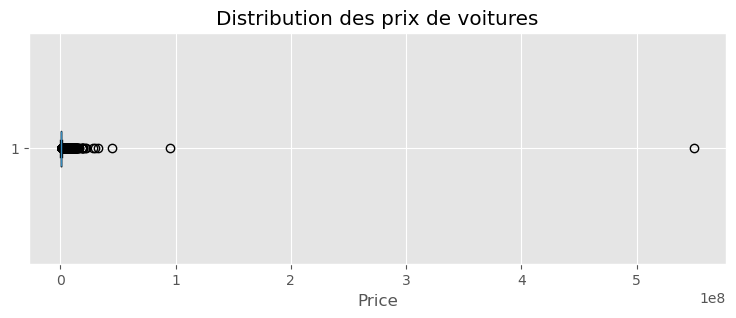

In [10]:
# Visualiser la distribution à l'aide d'une boîte à moustaches (Boxplot)

plt.figure(figsize=(9, 3))
plt.boxplot(df['Price'], vert=False, patch_artist=False)
plt.title('Distribution des prix de voitures')
plt.xlabel('Price')
plt.show()

#### 5.2- Quel est le nombre de valeurs aberrantes ?

Pour identifier les valeurs aberrantes on peut utiliser la méthode basée sur l'écart interquartile (IQR)

Procédure :

---

### **1. **Calcul de l’IQR (Interquartile Range)**
- **Q1 (Premier Quartile)** :
  - `Q1 = df['Price'].quantile(0.25)`: Calcule la valeur à la 25e percentile de la colonne `'Price'`.
  - Ce quartile représente la médiane des valeurs inférieures à la médiane totale.

- **Q3 (Troisième Quartile)** :
  - `Q3 = df['Price'].quantile(0.75)`: Calcule la valeur à la 75e percentile de la colonne `'Price'`.
  - Ce quartile représente la médiane des valeurs supérieures à la médiane totale.

- **IQR (Écart Interquartile)** :
  - `IQR = Q3 - Q1`: Calcule l’étendue du 1er quartile à la 3e quartile.
  - C’est un indicateur de la dispersion des données. Il représente l’écart entre les 25e et 75e percentiles.
  
### **2. Définition des bornes inférieure et supérieure**
- **Bord inférieur (Lower Bound)** :
  - `lower_bound = Q1 - 1.5 * IQR` :
    - Le `1.5 * IQR` est un facteur arbitraire utilisé pour identifier les valeurs aberrantes.
    - Toute valeur inférieure à `Q1 - 1.5 * IQR` est considérée comme un outlier (valeur aberrante).
  
- **Bord supérieur (Upper Bound)** :
  - `upper_bound = Q3 + 1.5 * IQR` :
    - Toute valeur supérieure à `Q3 + 1.5 * IQR` est également considérée comme un outlier.
  
### **3. Identification des outliers**
- **Définition du masque des outliers** :
  - `outliers = (df['Price'] < lower_bound) | (df['Price'] > upper_bound)` :
    - On compare chaque valeur de la colonne `'Price'` aux bornes définies (`lower_bound` et `upper_bound`).
    - Les valeurs qui sont en dehors de ces bornes sont identifiées comme `True`, sinon `False`.
  
### **4. Calcul du nombre d’outliers**
- **`num_outliers = outliers.sum()`** :
  - Utilise la fonction `.sum()` sur le masque `outliers` pour compter le nombre de `True` (c’est-à-dire le nombre de valeurs aberrantes).

---

### **Explication détaillée**

- **Pourquoi utiliser l’IQR pour détecter les outliers** ?
  - L’IQR est une méthode robuste pour détecter les valeurs aberrantes par rapport aux moyennes, car il ignore les valeurs extrêmes qui peuvent biaiser la moyenne (comme les moyennes, les écarts types, etc.).
  - En utilisant `1.5 * IQR`, on couvre environ 99.3% des valeurs normales dans une distribution gaussienne. Cela signifie que la majorité des données se situe à l’intérieur de ces bornes.

- **Calcul des quartiles** :
  - Le quartile 1 (`Q1`) est le point de coupure inférieur de la distribution, tandis que le quartile 3 (`Q3`) est le point de coupure supérieur.
  - L’IQR est l’écart entre `Q3` et `Q1`, fournissant une mesure de la dispersion du milieu de la distribution.

- **Identification des valeurs aberrantes** :
  - Toute donnée en dehors de `Q1 - 1.5 * IQR` ou `Q3 + 1.5 * IQR` est classée comme une valeur aberrante.
  - Cette méthode est couramment utilisée dans le nettoyage des données pour supprimer les outliers qui pourraient biaiser les analyses.

---

### **Exemple pratique**
Supposons que la colonne `'Price'` dans le DataFrame `df` ait les valeurs suivantes :
```
[10, 12, 15, 18, 200, 25, 22, 18, 15, 50]
```

- **Calcul des quartiles** :
  - `Q1 = 12` (25e percentile)
  - `Q3 = 18` (75e percentile)
  - `IQR = Q3 - Q1 = 18 - 12 = 6`

- **Définition des bornes** :
  - `lower_bound = Q1 - 1.5 * IQR = 12 - 1.5 * 6 = 3`
  - `upper_bound = Q3 + 1.5 * IQR = 18 + 1.5 * 6 = 27`

- **Identification des outliers** :
  - Les valeurs `10` et `200` seront identifiées comme des outliers car elles sont en dehors des bornes `[3, 27]`.

Ce processus permet de filtrer les données et d’identifier les observations qui pourraient perturber l’analyse statistique ou les modèles.

#### Application à notre dataset : Identification des valeurs aberrantes

- Calcul de  l'écart inter quartiles

In [12]:
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)

IQR = Q3 - Q1
print(f"1er q: ${Q1} \n 2e q: ${Q3} \n écart ${IQR}")

1er q: $319000.0 
 2e q: $890000.0 
 écart $571000.0


- Définir les limites inférieures et supérieures

In [13]:
lower_bound = Q1 - 1.5 * IQR
print(lower_bound)

-537500.0


- Identifier les valeurs aberrantes

In [14]:
upper_bound = Q3 + 1.5 * IQR
print(upper_bound)

1746500.0


- Compter le nombre de valeurs aberrantes

In [15]:
outliers = (df['Price'] < lower_bound) | (df['Price'] > upper_bound)
num_outliers = outliers.sum()
print(num_outliers)
print(outliers)

2834
0        False
1        False
2        False
3        False
4        False
         ...  
34099    False
34100    False
34101    False
34102    False
34103    False
Name: Price, Length: 34104, dtype: bool


#### Suppression des valeurs aberrantes

In [16]:
df= df.drop(df[(df['Price'] < lower_bound) | (df['Price'] > upper_bound)].index)

In [17]:
df.tail(12)

,Body,Transmission,Fuel,Brand,Model,Price,Color,Length,Width,Height,Wheel Base,Gear Box,Seats,Cargo Volume,Max Torque At
34088,hatchback,manual,diesel,tata,tata tiago,460000,brown,3746.0,1647.0,1535.0,2400.0,5 speed,5.0,242.0,2400.0
34089,suv,manual,diesel,tata,tata nexon,1350000,black,3993.0,1811.0,1606.0,2498.0,6 speed,5.0,350.0,2125.0
34090,suv,manual,diesel,tata,tata harrier,1293000,white,4598.0,1894.0,1706.0,2741.0,6 speed,5.0,425.0,2125.0
34094,suv,automatic,diesel,tata,tata nexon,1295000,grey,3994.0,1811.0,1607.0,2498.0,6 speed,5.0,350.0,2125.0
34095,suv,automatic,diesel,tata,tata nexon,913000,white,3994.0,1811.0,1607.0,2498.0,6 speed,5.0,350.0,2125.0
34096,suv,manual,diesel,tata,tata safari storme,685000,brown,4655.0,1965.0,1922.0,2650.0,5 speed,7.0,350.0,2200.0
34097,suv,manual,diesel,tata,tata nexon,760000,blue,3994.0,1811.0,1607.0,2498.0,6 speed,5.0,350.0,2125.0
34099,suv,manual,diesel,tata,tata nexon,881000,blue,3994.0,1811.0,1607.0,2498.0,6 speed,5.0,350.0,2125.0
34100,sedan,manual,diesel,tata,tata manza,245000,white,4413.0,1703.0,1550.0,2520.0,5 speed,5.0,460.0,2375.0
34101,hatchback,manual,diesel,tata,tata altroz,735000,grey,3990.0,1755.0,1523.0,2501.0,5 speed,5.0,345.0,2125.0


In [18]:
# Afficher la nouvelle taille du dataset
df.shape

(31270, 15)

#### 5.3- Quelle est la répartition des prix des voitures après avoir supprimé les valeurs aberrantes ?

- Visualiser la distribution à l'aide d'une boîte à moustaches (Boxplot)

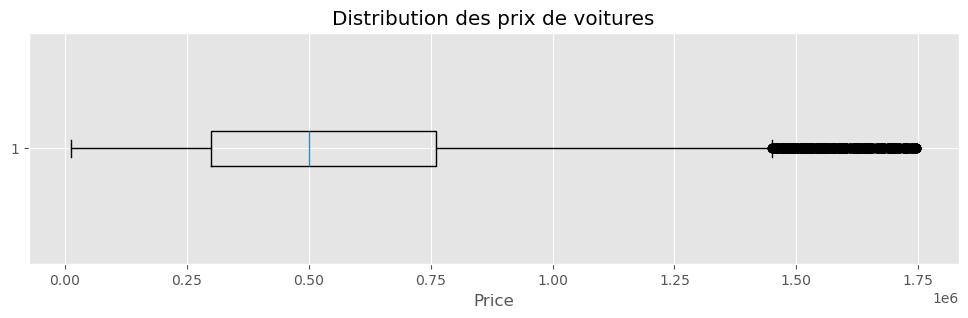

In [19]:
plt.figure(figsize=(12,3))
plt.boxplot(df["Price"], vert=False, patch_artist=False)
plt.title("Distribution des prix de voitures")
plt.xlabel("Price")
plt.show()


- Visualiser la distribution avec un histogramme

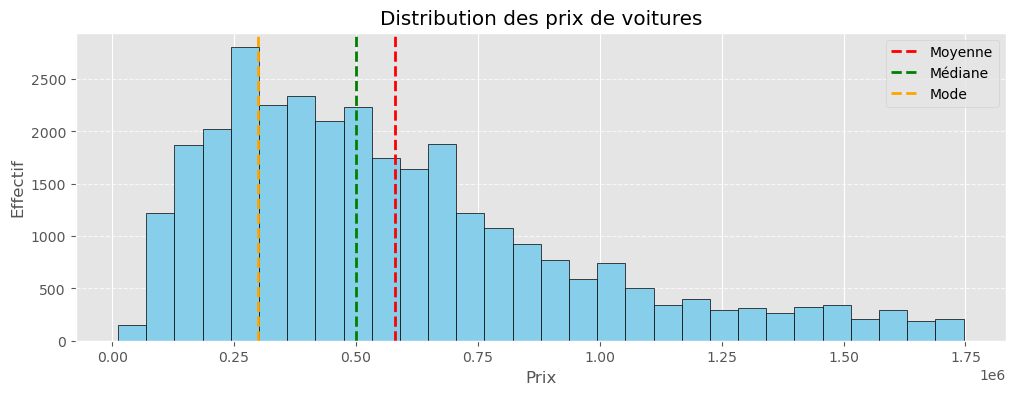

In [20]:
plt.figure(figsize=(12, 4))
plt.hist(df['Price'], bins=30, color='skyblue', edgecolor='black')

# Ajouter des lignes pour la moyenne, la médiane et le mode
plt.axvline(df['Price'].mean(), color='red', linestyle='dashed', linewidth=2, label='Moyenne')

plt.axvline(df['Price'].median(), color='green', linestyle='dashed', linewidth=2, label='Médiane')

plt.axvline(df['Price'].mode().iloc[0], color='orange', linestyle='dashed', linewidth=2, label='Mode')

plt.title('Distribution des prix de voitures')
plt.xlabel('Prix')
plt.ylabel('Effectif')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### 6- Comment varie le montant total des ventes (Variable Price) selon le type de carrosserie (Variable Body) ?

- Il s'agit de représenter un diagramme en bandes où chaque barre représente le prix total correspondant chaque carrosserie

- Donc dans un premier temps il faudrait sommer les prix par carrosserie et stocker dans une variable

- Trier le dataframe par ordre décroissant ou croissant des prix (optionnel mais recommandé pour une meilleure lisibilité du graphe)

- Ensuite faire le graphe

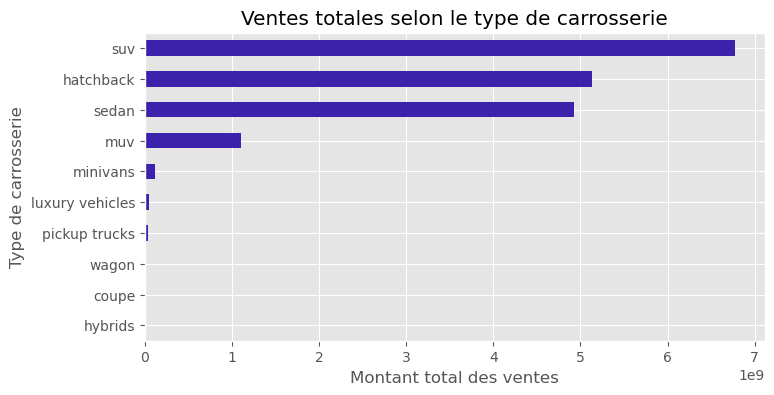

In [21]:
# Visualiser la valeur totale des ventes par type de carrosserie

plt.figure(figsize=(8, 4))

body_sales = df.groupby('Body')['Price'].sum()

body_sales = body_sales.sort_values(ascending=True)

body_sales.plot(kind='barh', color='#3c22ab')


plt.title('Ventes totales selon le type de carrosserie')
plt.xlabel('Montant total des ventes')
plt.ylabel('Type de carrosserie')
plt.show()

#### 7- Quelles sont les 10 premières marques (Variable Brand) par prix moyen de voiture ?

- Ici il faudrait calculer le prix moyen par marque de voiture et stocker dans une variable

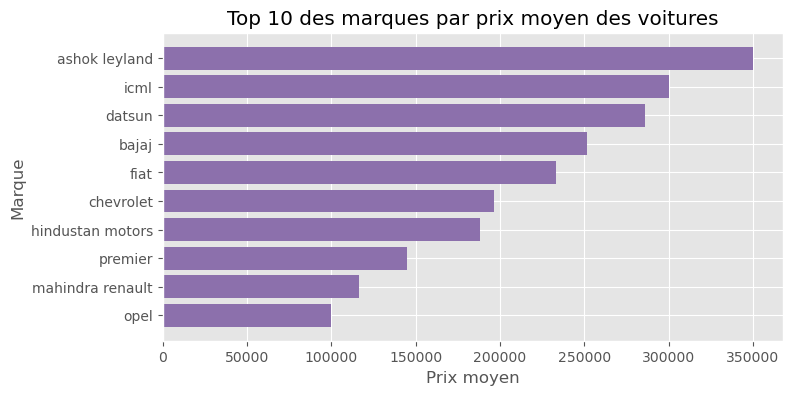

In [22]:
# Visualiser les prix moyens des voitures pour les 10 premières marques

plt.figure(figsize=(8, 4))

brand_avg_price = df.groupby('Brand')['Price'].mean()

top_10_brands = brand_avg_price.sort_values(ascending=True).head(10)

plt.barh(top_10_brands.index, top_10_brands, color='#8c70ac')


plt.title('Top 10 des marques par prix moyen des voitures')
plt.xlabel('Prix moyen')
plt.ylabel('Marque')
plt.show()

#### 8- Quelles sont les 10 couleurs (Variable Color) les plus populaires en fonction du prix moyen d'une voiture ?

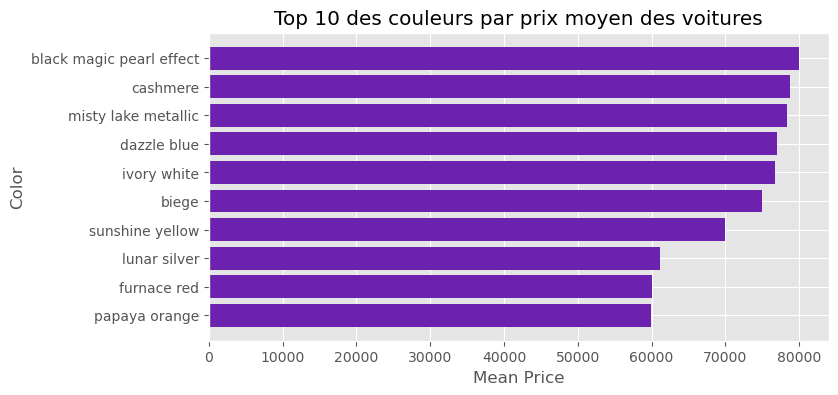

In [23]:
# Visualiser les prix moyens des voitures pour les 10 couleurs les plus populaires
plt.figure(figsize=(8,4))

colors_mean= df.groupby("Color")["Price"].mean()
colors_10_first= colors_mean.sort_values(ascending=True).head(10)

plt.barh(colors_10_first.index, colors_10_first, color= "#6c22af")
plt.title("Top 10 des couleurs par prix moyen des voitures")
plt.ylabel("Color")
plt.xlabel("Mean Price")
plt.show()

In [24]:
colors_10_first

Color
papaya orange               59889.666667
furnace red                 60000.000000
lunar silver                61136.250000
sunshine yellow             70000.000000
biege                       74999.000000
ivory white                 76666.666667
dazzle blue                 77000.000000
misty lake metallic         78333.333333
cashmere                    78750.000000
black magic pearl effect    80000.000000
Name: Price, dtype: float64

#### 9- Quelle est la répartition des transmissions (Variable Transmission) de voitures dans l'ensemble de données ?

Utiliser un diagramme circulaire

In [25]:
df['Transmission'].unique()

array(['manual', 'automatic'], dtype=object)

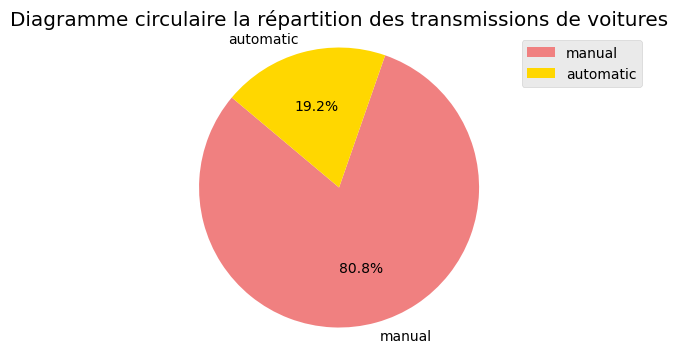

In [26]:
# Visualiser la distribution des transmissions automobiles

sizes = df['Transmission'].value_counts()
colors = ["lightcoral",'gold']
labels = sizes.index  # Les modalités uniques i.e: ['manual', 'automatic']

# Création du diagramme circulaire
plt.figure(figsize = (8,4))

plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)

plt.axis('equal')  # Assure que le diagramme est un cercle

plt.title("Diagramme circulaire la répartition des transmissions de voitures")
plt.legend()
plt.show()

### `Ou encore`

In [27]:
import plotly.express as px

data = {'Transmission': labels, 'Values': sizes}
fig = px.pie(data, values='Values', names='Transmission', title='Diagramme circulaire la répartition des transmissions de voitures')
fig.show()

#### 10- Quel est le volume de chargement moyen (Variable cargo) par type de carrosserie (Variable body) ?

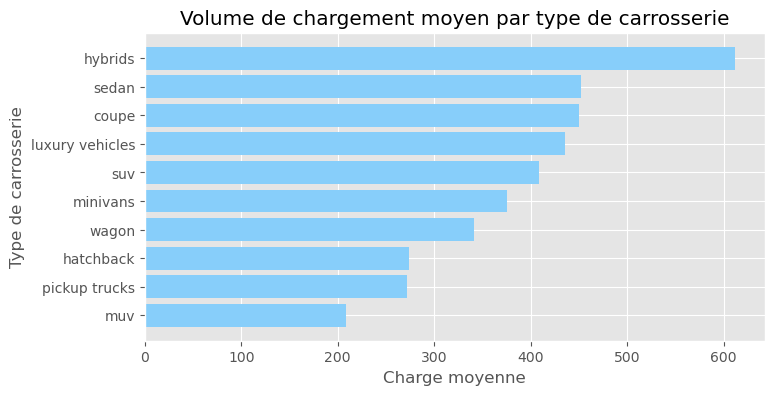

In [28]:
# Visualiser le volume de chargement moyen par type de carrosserie

plt.figure(figsize=(8,4))

cargo_volume= df.groupby("Body")["Cargo Volume"].mean().sort_values(ascending=True) 
plt.barh(cargo_volume.index, cargo_volume, color="lightskyblue")

plt.title("Volume de chargement moyen par type de carrosserie")
plt.xlabel("Charge moyenne")
plt.ylabel("Type de carrosserie")

plt.show()

#### 11- Quelle est la corrélation entre les variables numériques ?

- Afficher les noms de variable

In [29]:
df.columns

Index(['Body', 'Transmission', 'Fuel', 'Brand', 'Model', 'Price', 'Color',
       'Length', 'Width', 'Height', 'Wheel Base', 'Gear Box', 'Seats',
       'Cargo Volume', 'Max Torque At'],
      dtype='object')

- Afficher le type de chaque variable

In [30]:
for v,i in zip(df.columns, range(0,15) ):
    print(f" {df.columns[i]} : {df[v].dtype} ")

 Body : object 
 Transmission : object 
 Fuel : object 
 Brand : object 
 Model : object 
 Price : int64 
 Color : object 
 Length : float64 
 Width : float64 
 Height : float64 
 Wheel Base : float64 
 Gear Box : object 
 Seats : float64 
 Cargo Volume : float64 
 Max Torque At : float64 


- Récupérer les variables numériques

In [31]:
numerical = []

for v in df.columns:
    if df[v].dtype in ['int64', 'float64']:
        numerical.append(v)

numerical

['Price',
 'Length',
 'Width',
 'Height',
 'Wheel Base',
 'Seats',
 'Cargo Volume',
 'Max Torque At']

- Carte thermique de corrélation

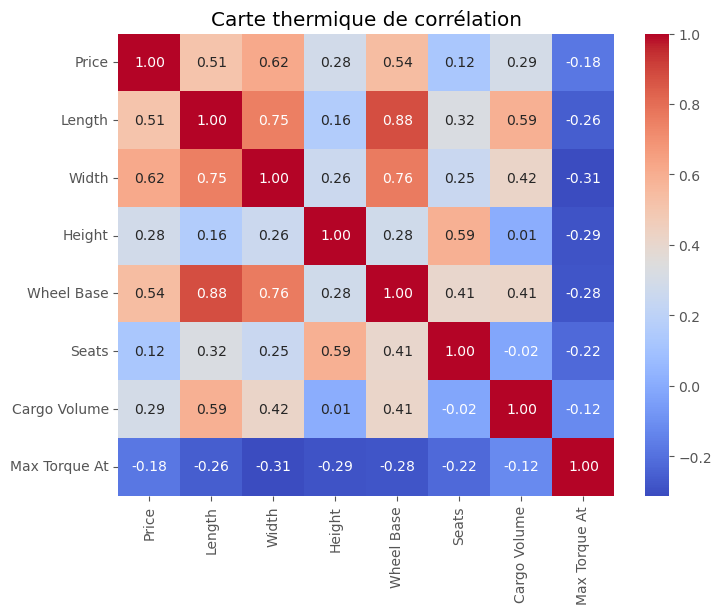

In [32]:
plt.figure(figsize=(8, 6) )
correlation_matrix = df[numerical].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Carte thermique de corrélation')
plt.show()

#### 12- Visualisez les corrélations précédentes avec la matice du nuage de points encore appelée diagramme de dispersion par paires (Pairwise Scatter Plot) et interpréter en combinaison avec la carte de corrélation précédente

Limitez-vous aux variables suivantes : ['Price', 'Length', 'Width', 'Height', 'Cargo Volume']

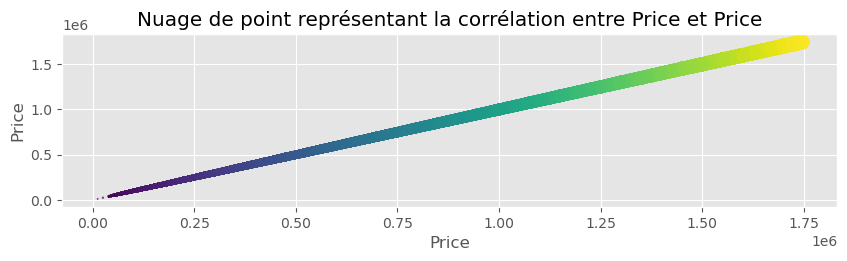

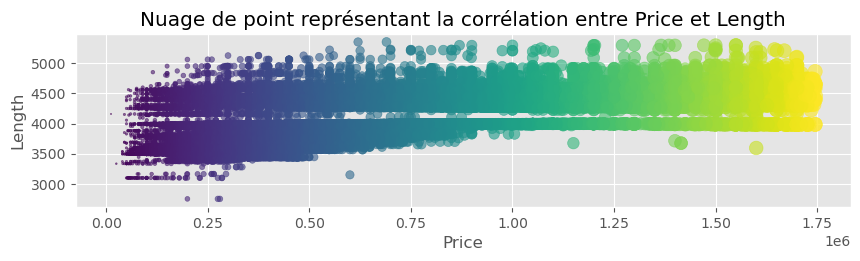

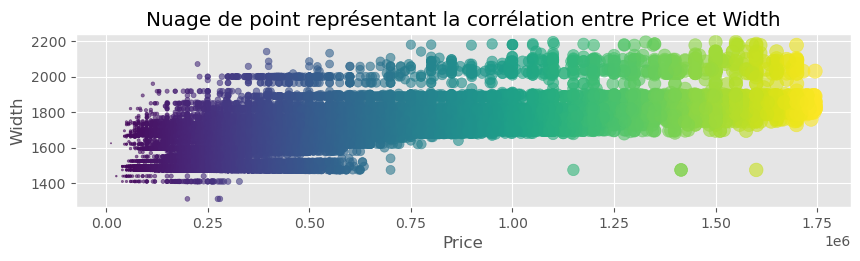

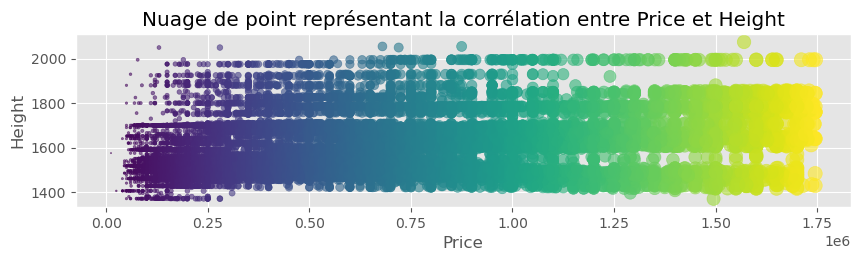

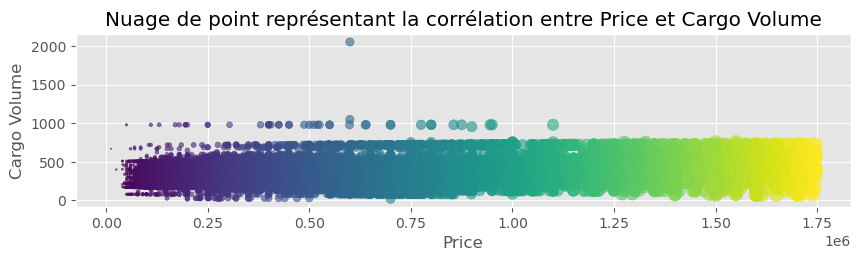

In [34]:
x= df[['Price', 'Length', 'Width', 'Height', 'Cargo Volume']]

for i,j in zip( range(x.shape[1]), range(1, x.shape[1]+1)):
    
    plt.figure(figsize=(10, 13))
        
    plt.subplot( x.shape[1], 1, j)
        
    plt.xlabel("Price")
    if i== 0:
        plt.ylabel("Price")
        title="Price"
        
    elif i== 1:
        plt.ylabel("Length")
        title="Length"
    elif i== 2:
        plt.ylabel("Width")
        title="Width"
    elif i== 3:
        plt.ylabel("Height")
        title="Height"
    else:
        plt.ylabel("Cargo Volume")
        title="Cargo Volume"

    plt.title(f"Nuage de point représentant la corrélation entre Price et {title}")
    plt.scatter(x.iloc[:, 0], x.iloc[:, i], c= x.iloc[:, 0], alpha= 0.6, s= x.iloc[:, 0]*0.00006)
    plt.show()

## `On peut déduire :`
#### `De la Carte thermique de corrélation qu'il y a une forte corrélation entre le prix d'une voiture et, sa longueur, sa largeur ,sa hauteur et son volume de charge ;` 

#### `Les nuages de points révèlent que la longueur et la largeur d'une voiture influencent fortement son prix.`
### C'est dire grosso modo, plus la voiture est longue et la large, plus est chère! 